In this notebook I will be testing my linear regression implementations. I built the following methods:
        1. Linear Regression
        2. Elastic Regression
        3. Ridge Regression
        4. Lasso Regression

I also developed a Polynomial Scaler as well that I will be utilizing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from LinearRegression.LinReg import LinearRegression
from LinearRegression.ElasticReg import ElasticRegression
from LinearRegression.LassoReg import LassoRegression
from LinearRegression.RidgeReg import RidgeRegression
from LinearRegression.PolyScaler import PolyScaler

from sklearn.linear_model import LinearRegression as LR_SK
from sklearn.linear_model import ElasticNet as ER_SK
from sklearn.linear_model import Lasso as LR_SK
from sklearn.linear_model import Ridge as RR_SK
from sklearn.preprocessing import PolynomialFeatures as POLY_SK
from sklearn.model_selection import train_test_split

Text(0, 0.5, 'y')

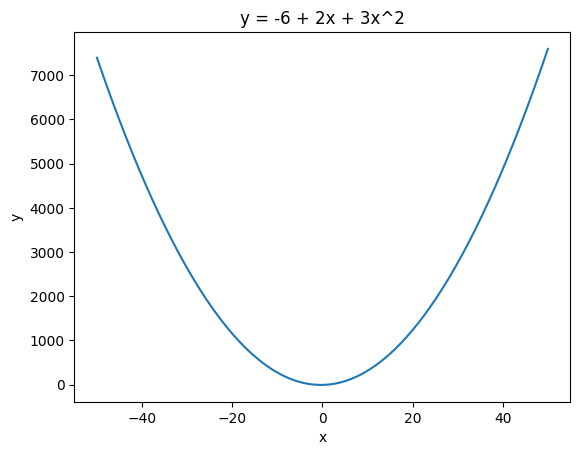

In [2]:
#y = 3x^2 + 2x - 6
X = np.linspace(-50, 50, 500)
y = 3*(X**2) + 2*X - 6

plt.plot(X, y)
plt.title('y = -6 + 2x + 3x^2')
plt.xlabel('x')
plt.ylabel('y')

In [3]:
#Separating the data into training and validation datasets
X_train, X_val, y_train_true, y_val = train_test_split(X, y, test_size = 0.2, random_state = 10)

sorted_train_idx = np.argsort(X_train)
X_train = X_train[sorted_train_idx]
y_train_true = y_train_true[sorted_train_idx]
noise = np.random.normal(0, 8, y_train_true.shape[0])

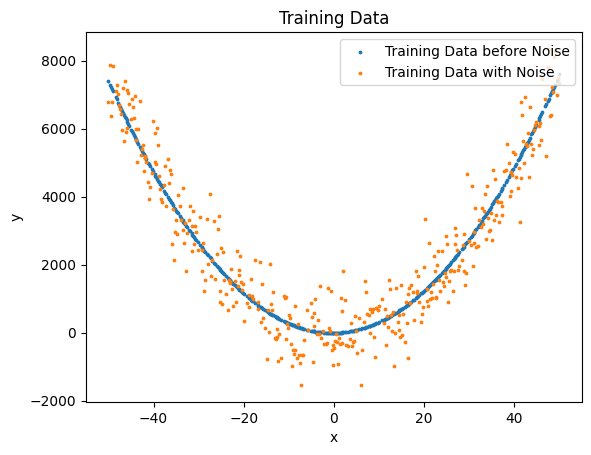

In [4]:
#Training Data
sorted_train_idx = np.argsort(X_train)
X_train = X_train[sorted_train_idx]
y_train_true = y_train_true[sorted_train_idx]
noise = np.random.normal(0, 0.3 * y_train_true.std(), y_train_true.shape[0])
y_train = y_train_true + noise

plt.scatter(X_train, y_train_true, label = 'Training Data before Noise', s = 3)
plt.scatter(X_train, y_train, label = 'Training Data with Noise', s = 3)
plt.title('Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc = 'upper right')

Text(0.5, 1.0, 'Validation Data')

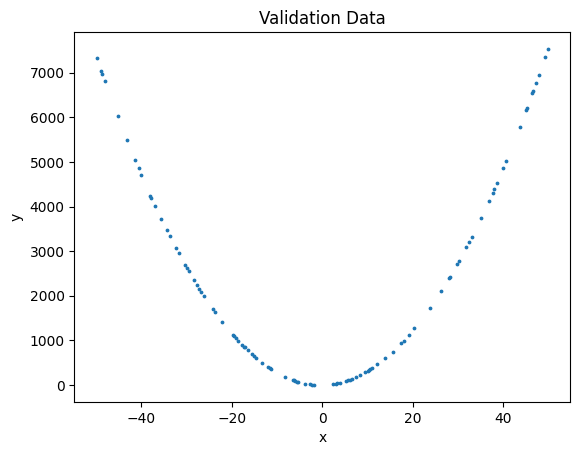

In [5]:
#Validation Data
sorted_val_idx = np.argsort(X_val)
X_val = X_val[sorted_val_idx]
y_val = y_val[sorted_val_idx]

plt.scatter(X_val, y_val, s = 3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Validation Data')

In [6]:
#Scaling the X data to be degree 2
poly2 = PolyScaler(degree = 2, include_bias = False)
poly2_sk = POLY_SK(degree = 2, include_bias = False)

X_train2 = poly2.fit_transform(X_train)
X_train2_sk = poly2_sk.fit_transform(X_train.reshape(-1, 1))

np.array_equal(X_train2, X_train2_sk)

True

Initialized a Linear Regression Model
[-4.67090411e+01  3.24102587e-02  3.05682955e+00]


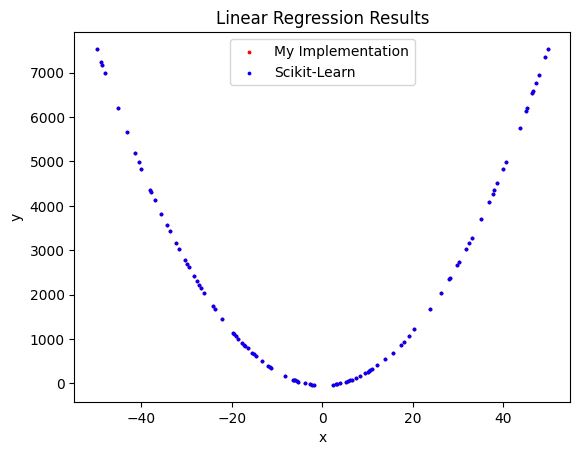

In [7]:
#Regular Linear Regression
LinReg = LinearRegression()
LinReg_SK = LR_SK()

LinReg.fit(X_train2, y_train)
LinReg_SK.fit(X_train2, y_train)

#Fitting the validation data to be degree 2
X_val2 = poly2.fit_transform(X_val)

#Prediction
lr_pred = LinReg.predict(X_val2)
lr_sk_pred = LinReg_SK.predict(X_val2)

plt.scatter(X_val, lr_pred, label = 'My Implementation', s = 3, color = 'red')
plt.scatter(X_val, lr_sk_pred, label = 'Scikit-Learn', s = 3, color = 'blue')
plt.title('Linear Regression Results')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

In [8]:
print('My implementation Theta Values: ', LinReg._theta)
print('Scikit-Learn Theta Values: ', np.r_[LinReg_SK.intercept_, LinReg_SK.coef_.flatten()])

My implementation Theta Values:  [-4.67090411e+01  3.24102587e-02  3.05682955e+00]
Scikit-Learn Theta Values:  [-4.67063452e+01  3.12228953e-02  3.05682670e+00]


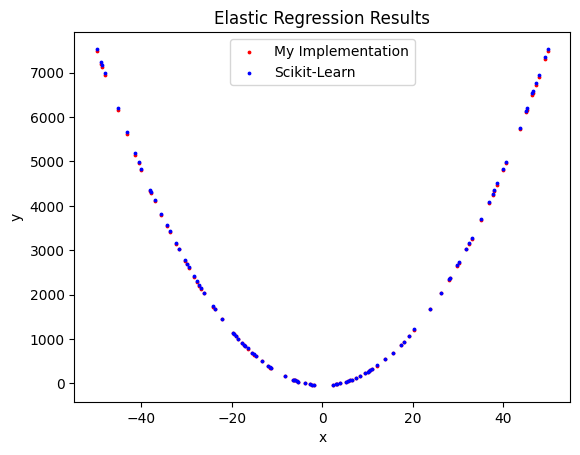

In [9]:
#Elastic Regression
ElasticReg = ElasticRegression(alpha = 0.01, l1_ratio = 0.4)
ElasticReg_SK = ER_SK(alpha = 0.01, l1_ratio = 0.4)

ElasticReg.fit(X_train2, y_train)
ElasticReg_SK.fit(X_train2, y_train)

er_pred = ElasticReg.predict(X_val2)
er_sk_pred = ElasticReg_SK.predict(X_val2)

plt.scatter(X_val, er_pred, label = 'My Implementation', s = 3, color = 'red')
plt.scatter(X_val, er_sk_pred, label = 'Scikit-Learn', s = 3, color = 'blue')
plt.title('Elastic Regression Results')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()


In [10]:
print('My implementation Theta Values: ', ElasticReg._theta)
print('Scikit-Learn Theta Values: ', np.r_[ElasticReg_SK.intercept_, ElasticReg_SK.coef_.flatten()])

My implementation Theta Values:  [-4.64147489e+01  2.09787237e-02  3.03845674e+00]
Scikit-Learn Theta Values:  [-4.67090021e+01  3.24052593e-02  3.05682950e+00]


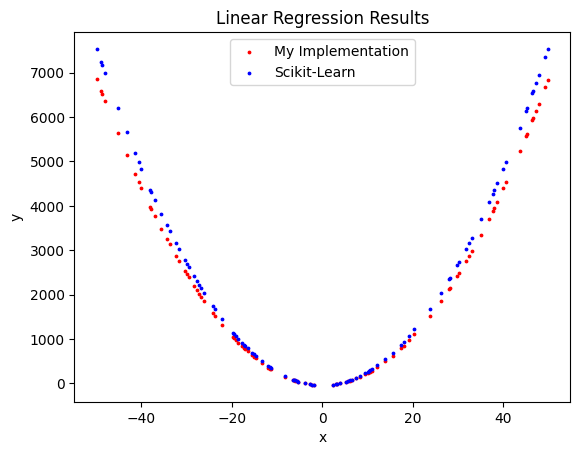

In [ ]:
#Ridge Regression
RidgeReg = RidgeRegression()
RidgeReg_SK = RR_SK()

RidgeReg.fit(X_train2, y_train)
RidgeReg_SK.fit(X_train2, y_train)

#Fitting the validation data to be degree 2
X_val2 = poly2.fit_transform(X_val)

#Prediction
rr_pred = RidgeReg.predict(X_val2)
rr_sk_pred = RidgeReg_SK.predict(X_val2)

plt.scatter(X_val, rr_pred, label = 'My Implementation', s = 3, color = 'red')
plt.scatter(X_val, rr_sk_pred, label = 'Scikit-Learn', s = 3, color = 'blue')
plt.title('Ridge Regression Results')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

In [13]:
print('My implementation Theta Values: ', RidgeReg._theta)
print('Scikit-Learn Theta Values: ', np.r_[RidgeReg_SK.intercept_, RidgeReg_SK.coef_.flatten()])

My implementation Theta Values:  [-42.32596954  -0.11552224   2.77877404]
Scikit-Learn Theta Values:  [-4.67090293e+01  3.24101546e-02  3.05682953e+00]


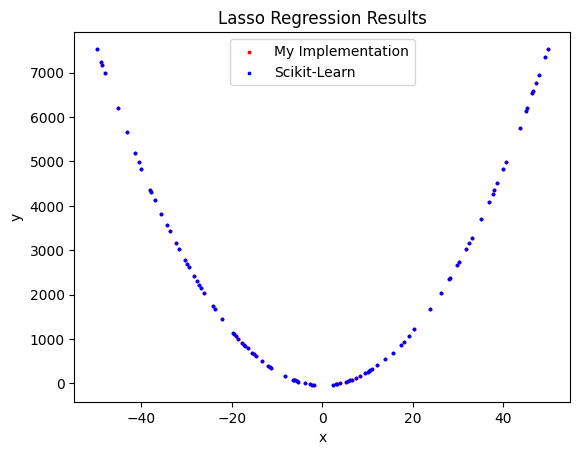

In [22]:
#Lasso Regression
LassoReg = LassoRegression()
LassoReg_SK = RR_SK()

LassoReg.fit(X_train2, y_train)
LassoReg_SK.fit(X_train2, y_train)

#Fitting the validation data to be degree 2
X_val2 = poly2.fit_transform(X_val)

#Prediction
lar_pred = LassoReg.predict(X_val2)
lar_sk_pred = LassoReg_SK.predict(X_val2)

plt.scatter(X_val, lar_pred, label = 'My Implementation', s = 3, color = 'red')
plt.scatter(X_val, lar_sk_pred, label = 'Scikit-Learn', s = 3, color = 'blue')
plt.title('Lasso Regression Results')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

In [15]:
print('My implementation Theta Values: ', LassoReg._theta)
print('Scikit-Learn Theta Values: ', np.r_[LassoReg_SK.intercept_, LassoReg_SK.coef_.flatten()])

My implementation Theta Values:  [-4.67023243e+01  3.12963842e-02  3.05668052e+00]
Scikit-Learn Theta Values:  [-4.67090293e+01  3.24101546e-02  3.05682953e+00]


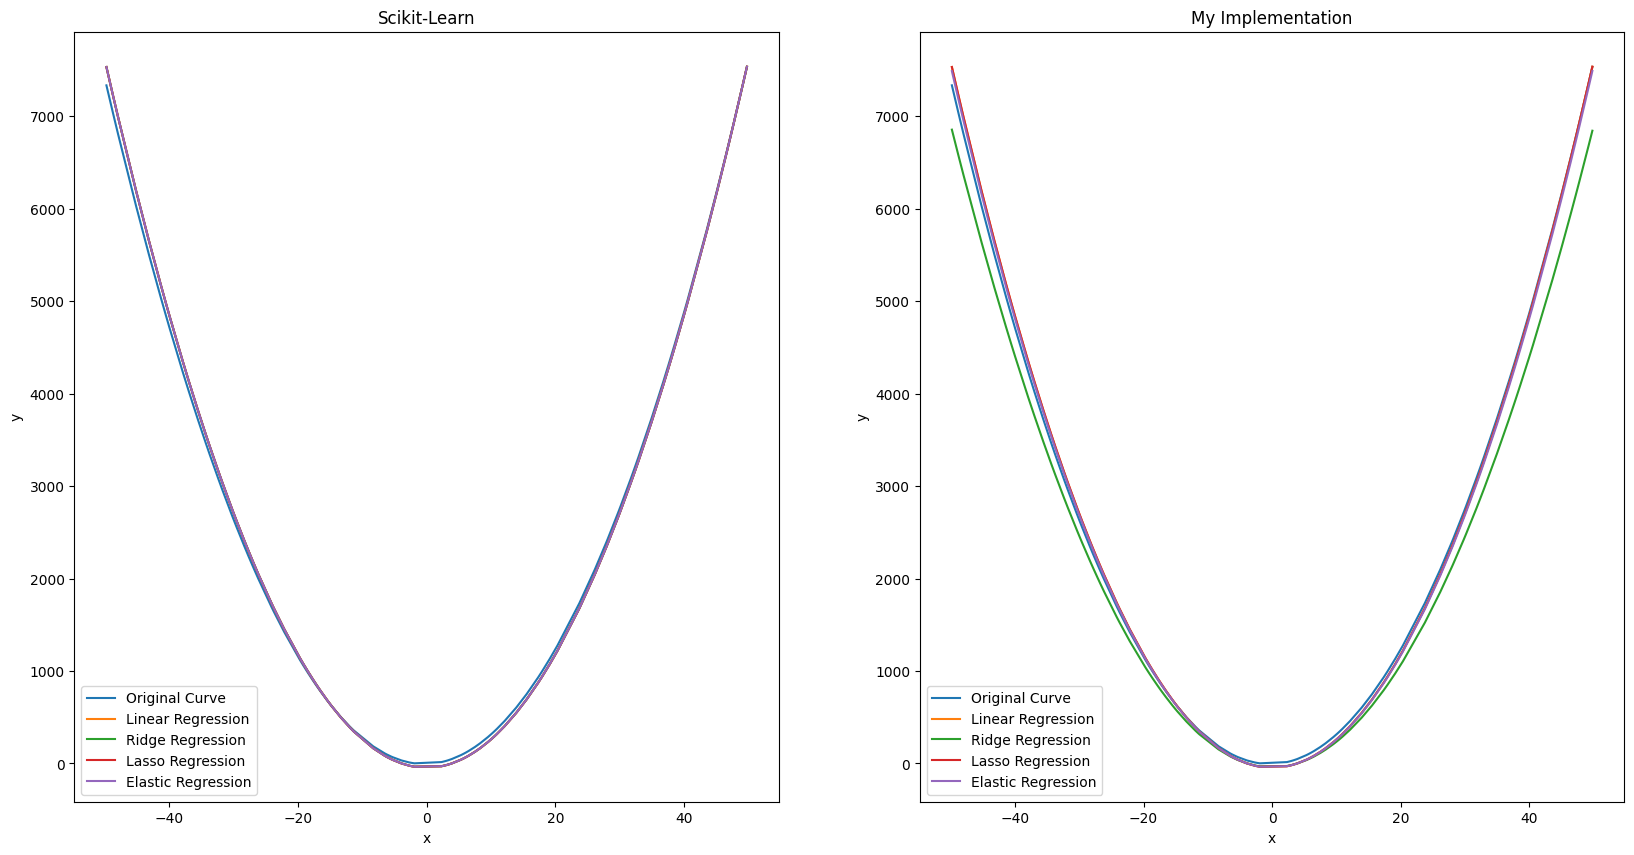

In [26]:
fig, ax = plt.subplots(1, 2, figsize = (20, 10))
ax[0].set_title('Scikit-Learn')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].plot(X_val, y_val, label = 'Original Curve')
ax[0].plot(X_val, lr_sk_pred, label = 'Linear Regression')
ax[0].plot(X_val, rr_sk_pred, label = 'Ridge Regression')
ax[0].plot(X_val, lar_sk_pred, label = 'Lasso Regression')
ax[0].plot(X_val, er_sk_pred, label = 'Elastic Regression')
ax[0].legend()

ax[1].set_title('My Implementation')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].plot(X_val, y_val, label = 'Original Curve')
ax[1].plot(X_val, lr_pred, label = 'Linear Regression')
ax[1].plot(X_val, rr_pred, label = 'Ridge Regression')
ax[1].plot(X_val, lar_pred, label = 'Lasso Regression')
ax[1].plot(X_val, er_pred, label = 'Elastic Regression')
ax[1].legend()